# Exploratory Data Analysis - Portfolio Allocation Engine

**COM-480 Data Visualization - Milestone 1**

This notebook explores the static dataset (`data/prices.csv`) covering daily adjusted closing prices for 9 assets from January 2010 to December 2025.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

## 1 - Load and inspect the data

In [2]:
prices = pd.read_csv("data/prices.csv", index_col="Date", parse_dates=True)
print(f"Shape: {prices.shape[0]} trading days x {prices.shape[1]} assets")
print(f"Period: {prices.index[0].date()} -> {prices.index[-1].date()}")
prices.head()

Shape: 4023 trading days x 9 assets
Period: 2010-01-04 -> 2025-12-30


,AAPL,MSFT,GOOGL,JPM,JNJ,SPY,QQQ,GLD,TLT
Date,,,,,,,,,
2010-01-04,6.412383,23.077381,15.555864,28.423937,40.204704,85.027946,40.341576,109.800003,56.359467
2010-01-05,6.423471,23.084845,15.487361,28.974485,39.738518,85.253006,40.341576,109.699997,56.723450
2010-01-06,6.321297,22.943169,15.096948,29.133698,40.061733,85.313072,40.098255,111.510002,55.964127
2010-01-07,6.309608,22.704567,14.745496,29.710804,39.775818,85.673187,40.124325,110.820000,56.058258
2010-01-08,6.351556,22.861145,14.942069,29.637829,39.912567,85.958267,40.454563,111.370003,56.033146


In [3]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4023 entries, 2010-01-04 to 2025-12-30
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    4023 non-null   float64
 1   MSFT    4023 non-null   float64
 2   GOOGL   4023 non-null   float64
 3   JPM     4023 non-null   float64
 4   JNJ     4023 non-null   float64
 5   SPY     4023 non-null   float64
 6   QQQ     4023 non-null   float64
 7   GLD     4023 non-null   float64
 8   TLT     4023 non-null   float64
dtypes: float64(9)
memory usage: 314.3 KB


In [4]:
prices.isnull().sum()

AAPL     0
MSFT     0
GOOGL    0
JPM      0
JNJ      0
SPY      0
QQQ      0
GLD      0
TLT      0
dtype: int64

No missing values after alignment, the fetch script already dropped incomplete rows.

## 2 - Compute daily log returns

In [5]:
log_ret = np.log(prices / prices.shift(1)).dropna()
print(f"Log-return matrix: {log_ret.shape[0]} obs x {log_ret.shape[1]} assets")
log_ret.head()

Log-return matrix: 4022 obs x 9 assets


,AAPL,MSFT,GOOGL,JPM,JNJ,SPY,QQQ,GLD,TLT
Date,,,,,,,,,
2010-01-05,0.001728,0.000323,-0.004413,0.019184,-0.011663,0.002643,0.000000,-0.000911,0.006437
2010-01-06,-0.016034,-0.006156,-0.025532,0.005480,0.008101,0.000704,-0.006050,0.016365,-0.013477
2010-01-07,-0.001851,-0.010454,-0.023555,0.019615,-0.007162,0.004212,0.000650,-0.006207,0.001681
2010-01-08,0.006626,0.006873,0.013243,-0.002459,0.003432,0.003322,0.008197,0.004951,-0.000448
2010-01-11,-0.008861,-0.012802,-0.001513,-0.003363,0.000156,0.001396,-0.004090,0.013201,-0.005503


## 3 - Annualised return & volatility

In [6]:
TRADING_DAYS = 252

ann_ret = log_ret.mean() * TRADING_DAYS
ann_vol = log_ret.std() * np.sqrt(TRADING_DAYS)
sharpe  = ann_ret / ann_vol

summary = pd.DataFrame({
    "Ann. Return (%)": (ann_ret * 100).round(2),
    "Ann. Volatility (%)": (ann_vol * 100).round(2),
    "Sharpe Ratio": sharpe.round(3),
}).sort_values("Ann. Return (%)", ascending=False)

summary

,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio
AAPL,23.50,28.16,0.834
MSFT,19.10,25.48,0.749
GOOGL,18.82,27.60,0.682
QQQ,17.11,20.67,0.828
JPM,15.21,27.58,0.551
SPY,13.09,17.25,0.759
JNJ,10.23,16.92,0.605
GLD,8.08,15.85,0.510
TLT,2.74,15.10,0.181


## 4 - Risk vs. Return scatter

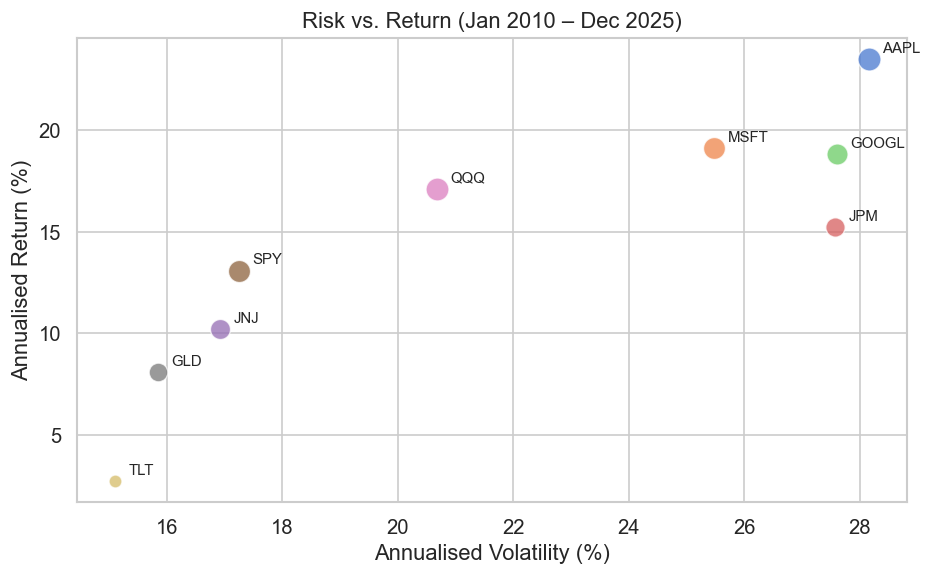

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sizes = (sharpe - sharpe.min() + 0.3) * 200

for ticker in ann_ret.index:
    ax.scatter(
        ann_vol[ticker] * 100, ann_ret[ticker] * 100,
        s=sizes[ticker], alpha=0.75, edgecolors="white", linewidth=0.8,
    )
    ax.annotate(ticker, (ann_vol[ticker] * 100, ann_ret[ticker] * 100),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.set_xlabel("Annualised Volatility (%)")
ax.set_ylabel("Annualised Return (%)")
ax.set_title("Risk vs. Return (Jan 2010 – Dec 2025)")
plt.tight_layout()
plt.show()

## 5 - Correlation matrix

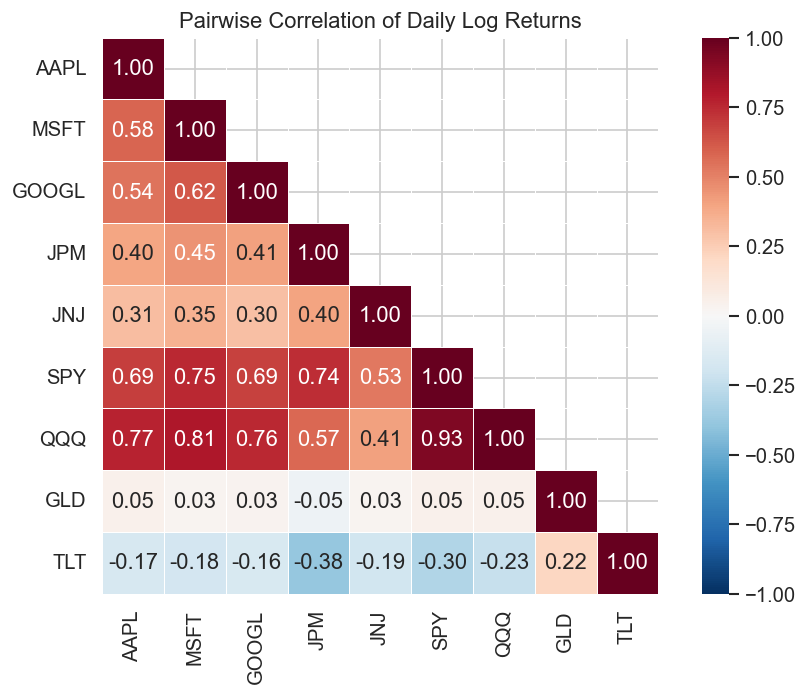

In [8]:
corr = log_ret.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Pairwise Correlation of Daily Log Returns")
plt.tight_layout()
plt.show()

In [9]:
print("Key diversification correlations:")
print(f"SPY - TLT : {corr.loc['SPY','TLT']:.2f}")
print(f"SPY - GLD : {corr.loc['SPY','GLD']:.2f}")

Key diversification correlations:
SPY - TLT : -0.30
SPY - GLD : 0.05


## 6 - Return distributions & normality tests

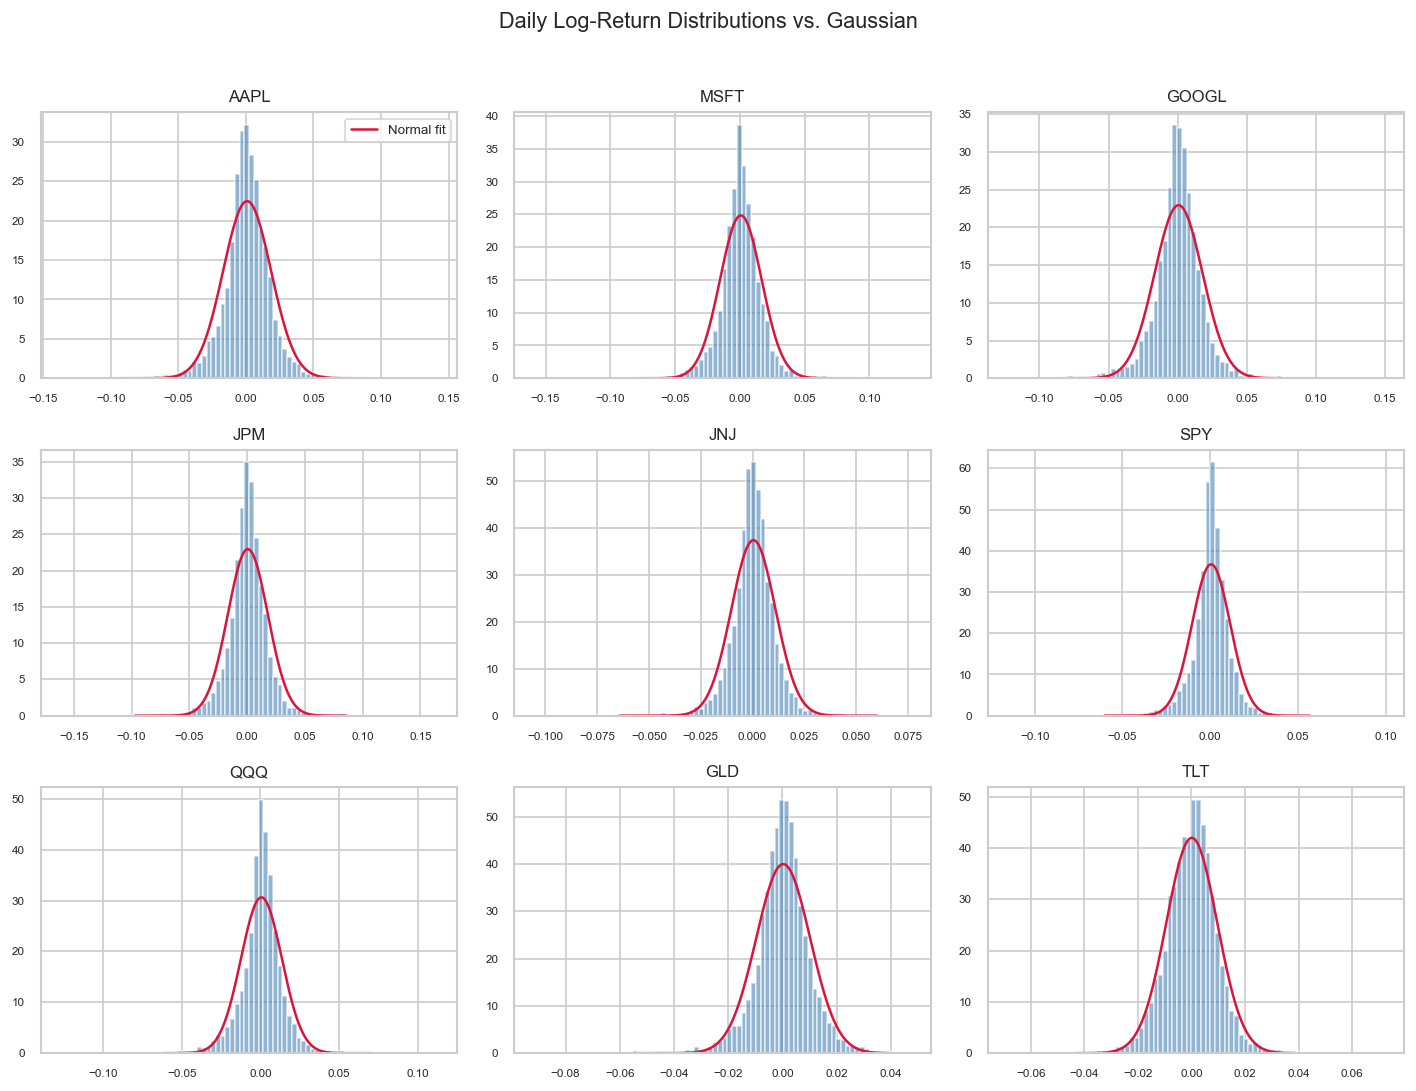

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=False)

for ax, ticker in zip(axes.flat, log_ret.columns):
    data = log_ret[ticker]
    ax.hist(data, bins=80, density=True, alpha=0.6, color="steelblue", edgecolor="white")
    xmin, xmax = data.quantile(0.001), data.quantile(0.999)
    xs = np.linspace(xmin, xmax, 200)
    ax.plot(xs, stats.norm.pdf(xs, data.mean(), data.std()),
            color="crimson", lw=1.5, label="Normal fit")
    ax.set_title(ticker, fontsize=10)
    ax.tick_params(labelsize=7)

axes[0, 0].legend(fontsize=8)
fig.suptitle("Daily Log-Return Distributions vs. Gaussian", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
dist_stats = pd.DataFrame({
    "Skewness": log_ret.skew().round(3),
    "Excess Kurtosis": log_ret.kurtosis().round(3),
    "Jarque-Bera stat": log_ret.apply(lambda c: stats.jarque_bera(c).statistic).round(1),
    "JB p-value": log_ret.apply(lambda c: stats.jarque_bera(c).pvalue).map(lambda p: f"{p:.2e}"),
})
dist_stats

,Skewness,Excess Kurtosis,Jarque-Bera stat,JB p-value
AAPL,-0.150,6.149,6331.9,0.00e+00
MSFT,-0.143,8.069,10894.4,0.00e+00
GOOGL,0.124,7.074,8371.6,0.00e+00
JPM,-0.112,9.549,15247.4,0.00e+00
JNJ,-0.331,9.398,14832.4,0.00e+00
SPY,-0.564,12.484,26258.6,0.00e+00
QQQ,-0.390,7.470,9425.5,0.00e+00
GLD,-0.517,4.768,3977.1,0.00e+00
TLT,-0.031,3.456,1995.7,0.00e+00


All assets reject the normality hypothesis (Jarque-Bera p ≈ 0), confirming fat tails and negative skewness across the board.

## 7 - Cumulative performance

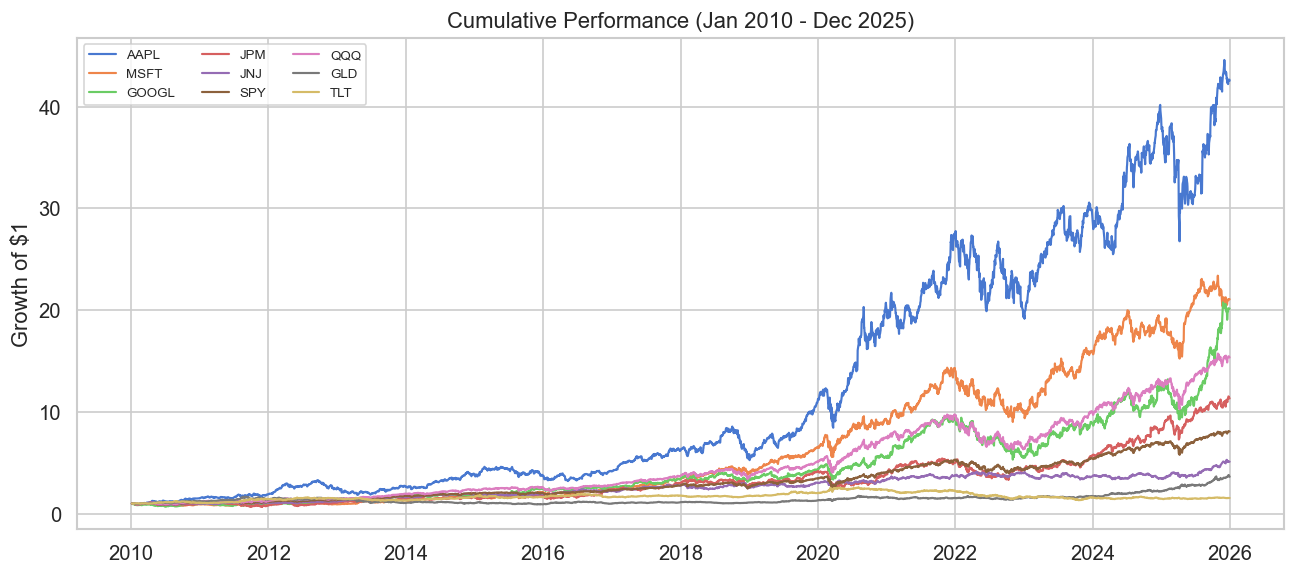

In [12]:
cum = np.exp(log_ret.cumsum())

fig, ax = plt.subplots(figsize=(11, 5))
for col in cum.columns:
    ax.plot(cum.index, cum[col], lw=1.3, label=col)

ax.set_ylabel("Growth of $1")
ax.set_title("Cumulative Performance (Jan 2010 - Dec 2025)")
ax.legend(ncol=3, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## 8 - Rolling volatility

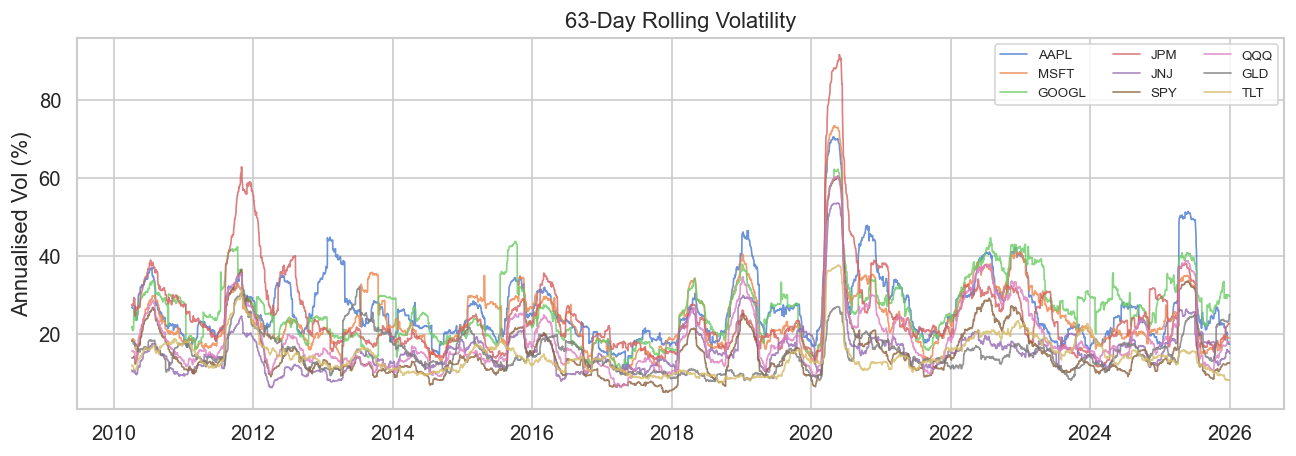

In [13]:
roll_vol = log_ret.rolling(63).std() * np.sqrt(TRADING_DAYS) * 100

fig, ax = plt.subplots(figsize=(11, 4))
for col in roll_vol.columns:
    ax.plot(roll_vol.index, roll_vol[col], lw=1, alpha=0.8, label=col)

ax.set_ylabel("Annualised Vol (%)")
ax.set_title("63-Day Rolling Volatility")
ax.legend(ncol=3, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

## Key takeaways

1. **Risk vs. Return trade-off**: Tech stocks (AAPL, MSFT, GOOGL, QQQ) delivered the highest returns but with significantly higher volatility.
2. **Diversification works**: TLT and GLD have low-to-negative correlation with equity assets, making them effective portfolio diversifiers.
3. **Non-normality is pervasive**: Every asset exhibits excess kurtosis and negative skewness; standard Gaussian assumptions underestimate tail risk.
4. **Volatility clusters**: Rolling vol spikes (e.g. COVID-19 in 2020) hit all assets simultaneously, reinforcing the need for robust covariance estimation.